# Robust Online Inertia Estimation Method
Adapted from Liu et al. "On-Line Inertia Estimation for Synchronous and Non-Synchronous Devices", specifically their E2 method, which takes into account the controller's damping and primary frequency control. This helps to remove oscillations in their estimated inertia. 

In [1]:
%matplotlib inline

from scipy.integrate import solve_ivp
from scipy.interpolate import make_splrep

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import andes

andes.config_logger(stream_level=30)

In [2]:
# path setup
from pathlib import Path
project_dir = Path.cwd()
test_case_dir = project_dir / "test_cases" # all test case excel sheets
disturbance_profile_dir = project_dir / "disturbance_profiles" # disturbance profiles for ANDES perturbation
out_dir = project_dir / "out"

case_path = andes.get_case(test_case_dir / "regcv2_testbench.xlsx")
STEP_TIME = 0.01 # 10 ms

## Load in case file and, run power flow and TDS

In [3]:
ss = andes.load(case_path, setup=False)
#ss.REGCV2.set("Tr",1,0.005)
#ss.REGF2.set("KPi",1,1)
#ss.REGF2.set("KPv",1,6)

#ss.REGCV2.set("D", 1, 7)
#ss.REGCV2.set("kw", 1, 20)
#ss.REGCV2.set("Kpvd", 1, 0.25)
#ss.REGCV2.set("Kpvq", 1, 0.25)
#ss.PV.set("p0", 1, 0)

ss.setup()
ss.config.warn_abnormal = 0
ss.PFlow.run()

ss.TDS.config.tf = 20 # Baruzzi et al ran simulation for 9s after disturbance
ss.TDS.config.store_f = 1 # store derivatives

ss.TDS.config.fixt = 1 # fixed step size
ss.TDS.config.tstep = 0.01 # matches Baruzzi et al. 

ss.TDS.config.no_tqdm = 1
ss.TDS.config.criteria = 1
ss.TDS.run()

True

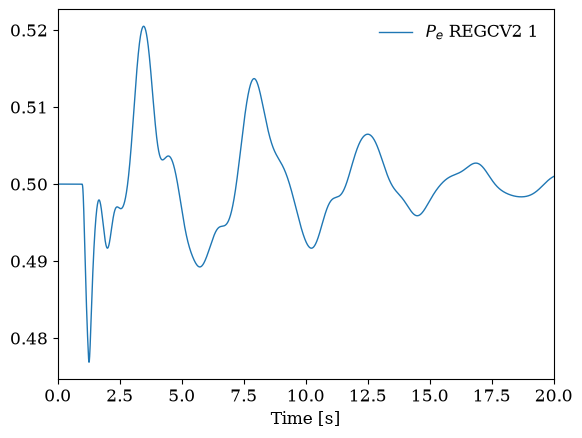

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='Time [s]'>)

In [4]:
ss.TDS.plot(ss.REGCV2.Pe)


In [5]:
# get frequency, RoCoF, and power time-series. 
"""
tds_df = pd.concat([ss.TDS.get_timeseries(ss.BusROCOF.f).loc[:,"BusROCOF_1"], 
                    ss.TDS.get_timeseries(ss.BusROCOF.Wf_y).loc[:,"BusROCOF_1"], 
                    ss.TDS.get_timeseries(ss.REGCV2.Pe)],
                    axis=1)
"""

dw_internal = ss.TDS.get_timeseries(ss.REGCV2.dw)

tds_df = pd.concat([ss.TDS.get_timeseries(ss.BusROCOF.f).loc[:,"BusROCOF_1"], 
                    dw_internal, 
                    ss.TDS.get_timeseries(ss.REGCV2.Pe)],
                    axis=1)

tds_df.columns = ["f", "df/dt", "p"]

tds_df

,f,df/dt,p
0.0000,1.000000,0.000000,0.500000
0.0001,1.000000,0.000000,0.500000
0.0009,1.000000,0.000000,0.500000
0.0010,1.000000,0.000000,0.500000
0.0011,1.000000,0.000000,0.500000
...,...,...,...
19.9989,0.999995,0.000048,0.500987
19.9990,0.999995,0.000048,0.500987
19.9991,0.999995,0.000048,0.500987
19.9999,0.999995,0.000048,0.500989


## Inertia Calculation

In [6]:
t0 = 0
tf = ss.TDS.config.tf

In [30]:
# calculate RoCoF, derivative of RoCoF (RoRoCOF?? lol), and derivative of power (RoCoP)
# need to interpolate between values b/c continuous-- called by solver

domega_dt = make_splrep(tds_df.index, tds_df.loc[:,"df/dt"], s=0.001)      
d2omega_dt2 = domega_dt.derivative()               
dp_dt = make_splrep(tds_df.index, tds_df.loc[:,"p"], s=0).derivative()

print(d2omega_dt2(tds_df.index))

tds_df.loc[:,"dp_dt"] = dp_dt(tds_df.index)
tds_df

[0.00011591 0.000116   0.00011673 ... 0.00041335 0.00041361 0.00041364]


,f,df/dt,p,dp_dt
0.0000,1.000000,0.000000,0.500000,0.000000e+00
0.0001,1.000000,0.000000,0.500000,-2.513515e-13
0.0009,1.000000,0.000000,0.500000,9.568104e-13
0.0010,1.000000,0.000000,0.500000,1.059758e-13
0.0011,1.000000,0.000000,0.500000,-7.031412e-13
...,...,...,...,...
19.9989,0.999995,0.000048,0.500987,1.574784e-03
19.9990,0.999995,0.000048,0.500987,1.573596e-03
19.9991,0.999995,0.000048,0.500987,1.572056e-03
19.9999,0.999995,0.000048,0.500989,1.568022e-03


In [31]:
def gamma(x, eps):
    return np.where(x >= eps, -1.0, np.where(x <= -eps, 1.0, 0.0))

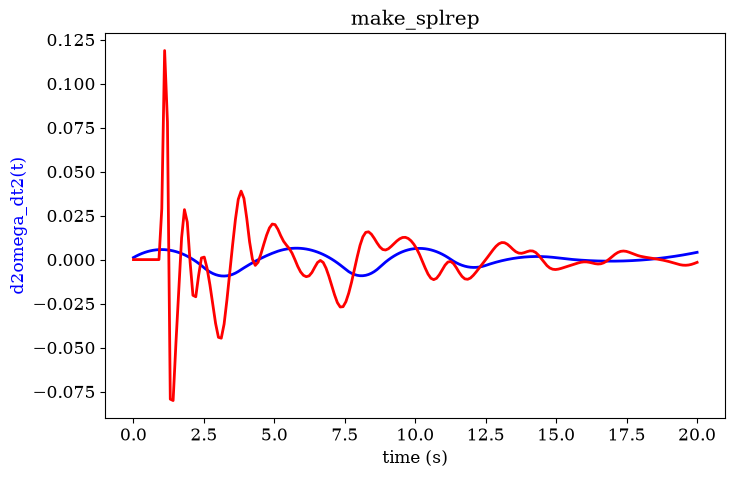

array([ 1.15912038e-04,  2.02823831e-04,  2.80534976e-04,  3.49045473e-04,
        4.08355323e-04,  4.58464525e-04,  4.99373080e-04,  5.31080987e-04,
        5.53588247e-04,  5.66894859e-04,  5.71000824e-04,  5.65906141e-04,
        5.51610811e-04,  5.28114833e-04,  4.95418208e-04,  4.53520935e-04,
        4.02423015e-04,  3.42124447e-04,  2.72625232e-04,  1.93925369e-04,
        1.06024859e-04,  8.92370103e-06, -9.73781043e-05, -2.12880557e-04,
       -3.37583657e-04, -4.71262142e-04, -5.96345485e-04, -7.01795794e-04,
       -7.87613066e-04, -8.53797304e-04, -9.00348506e-04, -9.27266672e-04,
       -9.34551803e-04, -9.22203899e-04, -8.90222959e-04, -8.38608984e-04,
       -7.67361974e-04, -6.76481928e-04, -5.71457279e-04, -4.68889402e-04,
       -3.69912268e-04, -2.74525880e-04, -1.82730236e-04, -9.45253367e-05,
       -9.91118198e-06,  7.11122281e-05,  1.48544894e-04,  2.22386814e-04,
        2.92637991e-04,  3.59298422e-04,  4.22230638e-04,  4.78410272e-04,
        5.26600084e-04,  

In [32]:
# 3. Generate high-density x-values for a smooth curve plot
x_smooth = np.linspace(0, 20, 200)
domega = d2omega_dt2(x_smooth)
dp = dp_dt(x_smooth)

# 4. Create the graph
fig, ax1 = plt.subplots(figsize=(8, 5))
#ax2 = ax1.twinx()

ax1.plot(x_smooth, domega * 10, '-', color='blue', label='domega', linewidth=2)
#ax1.plot(x_smooth, dp, '-', color='red', label='dp', linewidth=2)
ax1.plot(x_smooth, -dp, '-', color='red', label='dp', linewidth=2)


# 5. Format and display the plot
plt.title('make_splrep')
ax1.set_xlabel('time (s)')

ax1.set_ylabel('d2omega_dt2(t)', color="blue")
#ax2.set_ylabel('dp_dt(t)', color="red")

#ax1.set_xlim(5, 10)

#plt.legend()
#plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

domega

In [33]:
tds_df

,f,df/dt,p,dp_dt
0.0000,1.000000,0.000000,0.500000,0.000000e+00
0.0001,1.000000,0.000000,0.500000,-2.513515e-13
0.0009,1.000000,0.000000,0.500000,9.568104e-13
0.0010,1.000000,0.000000,0.500000,1.059758e-13
0.0011,1.000000,0.000000,0.500000,-7.031412e-13
...,...,...,...,...
19.9989,0.999995,0.000048,0.500987,1.574784e-03
19.9990,0.999995,0.000048,0.500987,1.573596e-03
19.9991,0.999995,0.000048,0.500987,1.572056e-03
19.9999,0.999995,0.000048,0.500989,1.568022e-03


## E0

In [34]:
EPS_O = 1e-6   # paper's VSG-case default
#t_since_onset = 30
t_est = tds_df.loc[1:].index.values
H_true = ss.REGCV2.M.v / 2

dp_dt_discrete = np.gradient(tds_df.loc[t_est]["p"].values, t_est)
domega_dt_discrete = np.gradient(tds_df.loc[t_est]["df/dt"].values, t_est)
d2omega_dt2_discrete = np.gradient(domega_dt_discrete, t_est)

M_E0 = np.zeros(len(t_est))
for i in range(len(t_est)):
    if abs(d2omega_dt2_discrete[i]) >= EPS_O:
        M_E0[i] = -dp_dt_discrete[i] / d2omega_dt2_discrete[i]
    else:
        M_E0[i] = M_E0[i - 1] if i > 0 else 0.0
H_E0 = M_E0 / 2


final_df = pd.DataFrame()
final_df.loc[:,'domega_dt'] = domega_dt_discrete
final_df.loc[:,'d2omega_dt2'] = d2omega_dt2_discrete
final_df.loc[:,'M_E0'] = M_E0
final_df.loc[:,'H_E0'] = H_E0

print(f'H_E0 median (t>=3s) = {np.median(H_E0[t_est >= 3.0]):.3f}   H_true = {H_true}')
print(f'H_E0 range          = [{H_E0.min():.2f}, {H_E0.max():.2f}]  (spikes expected, not removed)')


H_E0 median (t>=3s) = 5.116   H_true = [5.]
H_E0 range          = [-2818.94, 3011.78]  (spikes expected, not removed)


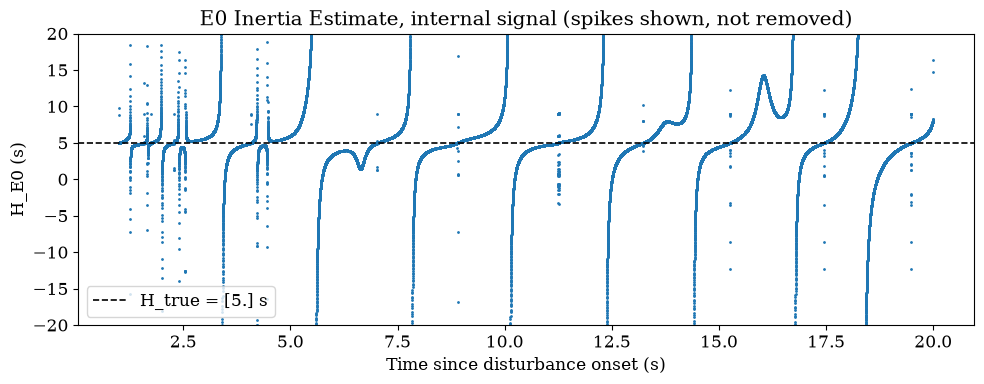

In [35]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_est, H_E0, '.', markersize=2, color='tab:blue')
ax.axhline(H_true, color='k', linewidth=1.2, linestyle='--', label=f'H_true = {H_true} s')
ax.set_ylim(-20, 20)
ax.set_xlabel('Time since disturbance onset (s)')
ax.set_ylabel('H_E0 (s)')
ax.set_title('E0 Inertia Estimate, internal signal (spikes shown, not removed)')
ax.legend(loc='best')
plt.tight_layout()
plt.show()


## E1

### No PI Filter

In [36]:
TM = 0.001
eps_x = 10e-6

In [37]:
def rhs_e1(t, y, TM, eps_x):
    Mstar = y
    d2w = d2omega_dt2(t)
    dp = dp_dt(t)

    dMstar = gamma(d2w, eps_x) * (dp + Mstar * d2w) / TM
    return dMstar

In [38]:
eps_x=10e-6
TM=0.001

sol_e1 = solve_ivp(rhs_e1, [t0, tf], y0=[0],
                 args=(TM, eps_x),
                 method='Radau',
                 dense_output=True,
                 t_eval=tds_df.index)

(-10.0, 20.0)

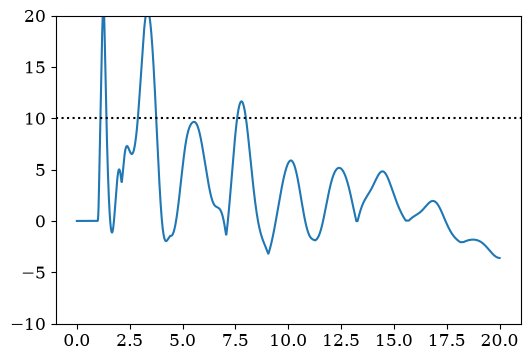

In [39]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sol_e1.t, sol_e1.y[0])
ax.axline((0, 10), slope=0, color="black", linestyle=":")
ax.set_ylim(-10, 20)
#ax.set_xlim(5, 6)

In [20]:
T_M = 0.001    # paper's VSG-case default
EPS_OMEGADOT = 1e-6

M_E1 = np.zeros(len(t_est))
for i in range(1, len(t_est)):
    dt_i = t_est[i] - t_est[i - 1]
    g = gamma(d2omega_dt2_discrete[i], EPS_OMEGADOT)
    a = g * dp_dt_discrete[i] / T_M
    b = g * d2omega_dt2_discrete[i] / T_M
    M_E1[i] = (M_E1[i - 1] + dt_i * a) / (1 - dt_i * b)
H_E1 = M_E1 / 2
final_df['M_E1'] = M_E1
final_df['H_E1'] = H_E1

print(f'H_E1 median (t>=3s) = {np.median(H_E1[t_est >= 3.0]):.3f}   H_true = {H_true}')
print(f'H_E1 range          = [{H_E1.min():.2f}, {H_E1.max():.2f}]')

H_E1 median (t>=3s) = 5.098   H_true = [5.]
H_E1 range          = [0.00, 6.29]


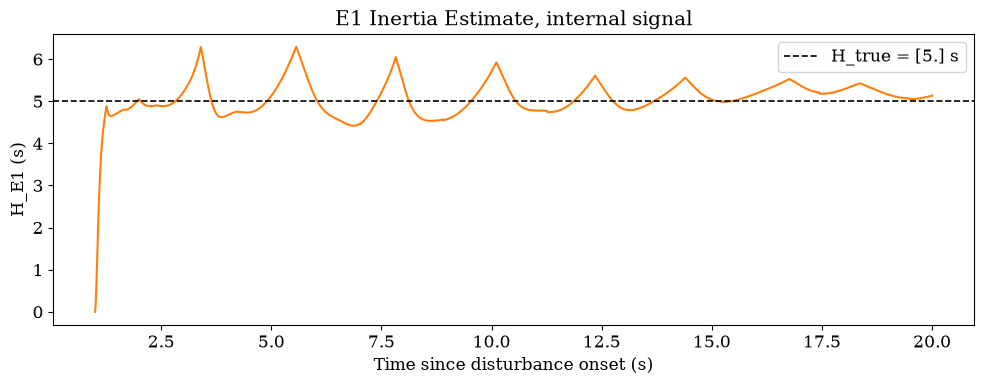

In [21]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_est, H_E1, color='tab:orange')
ax.axhline(H_true, color='k', linewidth=1.2, linestyle='--', label=f'H_true = {H_true} s')
ax.set_xlabel('Time since disturbance onset (s)')
ax.set_ylabel('H_E1 (s)')
ax.set_title('E1 Inertia Estimate, internal signal')
ax.legend(loc='best')
plt.tight_layout()
plt.show()


### With PI filter

In [16]:
TM = 0.001
Kp = 20
Ki = 1
TF = 0.0001
eps_x = 10e-6

"""
def rhs_e1_PI(t, y, TM, TF, eps_x):
    Mstar, dw_star, d2w_star = y
    
    dw_raw = domega_dt(t)
    dp = dp_dt(t)

    # PI filter things~
    error = dw_raw - dw_star
    dw_int = Ki * Kp * error

    ddw_star = (error - 2 * d2w_star) * Kp / TF

    # accumulation
    dMstar = gamma(d2w_star, eps_x) * (dp + Mstar * d2w_star) / TM

    return [dMstar, dw_int, ddw_star]

"""
def rhs_e1_PI(t, y, TM, TF, eps_x):
    Mstar, dw_star, xI = y

    dw_raw = domega_dt(t)
    dp = dp_dt(t)

    # Error between raw and filtered RoCoF
    error = dw_raw - dw_star

    # Integral state
    dxI = error

    # PI output
    u = Kp * error + Ki * xI

    # First-order filtered RoCoF
    ddw_star = (u - dw_star) / TF

    # Inertia estimator
    dMstar = gamma(ddw_star, eps_x) * (
        dp + Mstar * ddw_star
    ) / TM

    return [dMstar, ddw_star, dxI]

In [17]:
sol_e1_PI = solve_ivp(rhs_e1_PI, [t0, tf], y0=[0, 0, 0],
                 args=(TM, TF, eps_x),
                 method='Radau', 
                 dense_output=True,
                 t_eval=tds_df.index)

NameError: name 'sol_e1_PI' is not defined

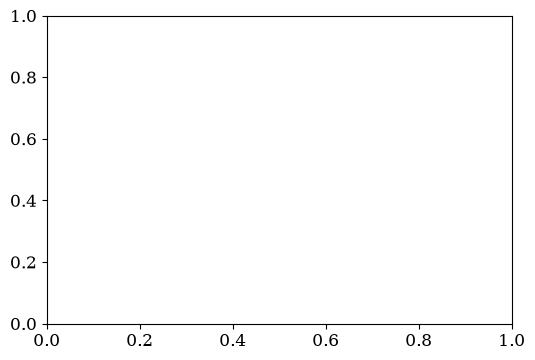

In [22]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sol_e1_PI.t, sol_e1_PI.y[0])
ax.axline((0, 5), slope=0, color="black", linestyle=":")
ax.set_ylim(-10, 20)
#ax.set_xlim(0, 6)

## E2

In [ ]:
TM = 0.01
Kp = 50
Ki = 1
TF = 0.1
TD = 10e-4
eps_x = 10e-6
eps_w = 10e-6

In [ ]:
def rhs_e2(t, y, TM, TD, TF, eps_x, eps_w):  
    Mstar, Dstar, domega_int, dp_int, dw_star, d2w_star = y

    dw_raw = domega_dt(t)
    dp = dp_dt(t)

    # KI filter things~
    error = dw_raw - dw_star
    dw_int = Ki * Kp * error
    ddw_star = (error * Kp - 2 * d2w_star)/ TF

    # calculations
    dMstar = gamma(d2w_star, eps_x) * (dp + Mstar*d2w_star + Dstar*dw_star) / TM
    dDstar = gamma(domega_int, eps_w) * (dp_int + Mstar*dw_star + Dstar*domega_int) / TD
    ddomega_int = dw_star    
 
    return [dMstar, dDstar, ddomega_int, dp, dw_int, ddw_star]

In [ ]:
sol_e2 = solve_ivp(rhs_e2, [t0, tf], y0=[0, 0, 0, 0, 0, 0],
                 args=(TM, TD, TF, eps_x, eps_w),
                 method='Radau', 
                 dense_output=True,
                 t_eval=tds_df.index)

#plt.show()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sol_e2.t, sol_e2.y[0])
#ax.axline((0, 5), slope=0, color="black", linestyle=":")
#ax.set_ylim(-10, 8)
#ax.set_xlim(0, 10)

In [ ]:
for t, mstar in zip(sol_e2.t, sol_e2.y[0]):
    if (t > 5 and t < 7):
        dp = dp_dt(t)
        d2w = d2omega_dt2(t)
        plt.scatter(t, d2w, color="blue", s=1)
        #print(f"t: {t:.4f} |gamma(d2w): {gamma(d2w, eps_x)} | Mstar: {mstar:.4f} | dp: {dp:.4f} | d2w: {d2w:.6f}")

In [ ]:
ss.TDS.plot(ss.BusFreq.f)

In [ ]:
ss.TDS.plot(ss.REGCV2.Pe)

In [61]:
delta_p

array([-0.00018206, -0.00018409, -0.00020077, ...,  0.00098739,
        0.00098864,  0.0009888 ], shape=(57001,))

In [60]:
T_M2, T_D2 = 0.001, 1e-4   # paper's VSG-case defaults
EPS_DOMEGA = 1e-6
D_configured = 5

delta_p = (tds_df["p"] - tds_df["p"][0]).loc[t_est].values
delta_omega = np.concatenate([[0.0], np.cumsum(
    (domega_dt_discrete[1:] + domega_dt_discrete[:-1]) / 2 * np.diff(t_est))])


def run_e2(omega_dot, omega_ddot, delta_omega, sign):
    """Backward (implicit) Euler for the coupled linear system
    dM/dt = A + B*M + C*D, dD/dt = E_ + F*M + G*D, i.e.
    [1-dt*B, -dt*C; -dt*F, 1-dt*G] @ [M;D] = [M_prev+dt*A; D_prev+dt*E_]."""
    M = np.zeros(len(t_est))
    D = np.zeros(len(t_est))
    for i in range(1, len(t_est)):
        dt_i = t_est[i] - t_est[i - 1]

        gM = gamma(omega_ddot[i], EPS_OMEGADOT)
        gD = gamma(delta_omega[i], EPS_DOMEGA)

        A = gM * dp_dt_discrete[i] / T_M2
        B = sign * gM * omega_ddot[i] / T_M2
        C = sign * gM * omega_dot[i] / T_M2
        E_ = gD * delta_p[i] / T_D2
        F = sign * gD * omega_dot[i] / T_D2
        G = sign * gD * delta_omega[i] / T_D2

        m11, m12 = 1 - dt_i * B, -dt_i * C
        m21, m22 = -dt_i * F, 1 - dt_i * G
        rhs1, rhs2 = M[i - 1] + dt_i * A, D[i - 1] + dt_i * E_
        det = m11 * m22 - m12 * m21
        M[i] = (rhs1 * m22 - m12 * rhs2) / det
        D[i] = (m11 * rhs2 - rhs1 * m21) / det

    return M, D


M_E2, D_E2 = run_e2(domega_dt_discrete, d2omega_dt2_discrete, delta_omega, sign=+1)
H_E2 = M_E2 / 2
final_df['M_E2'] = M_E2
final_df['D_E2'] = D_E2
final_df['H_E2'] = H_E2

print(f'H_E2 median (t>=3s) = {np.median(H_E2[t_est>=3.0]):.3f}   H_true = {H_true}')
print(f'D_E2 median (t>=3s) = {np.median(D_E2[t_est>=3.0]):.3f}   D_true = {D_configured}')


H_E2 median (t>=3s) = 4.991   H_true = [5.]
D_E2 median (t>=3s) = 4.992   D_true = 5


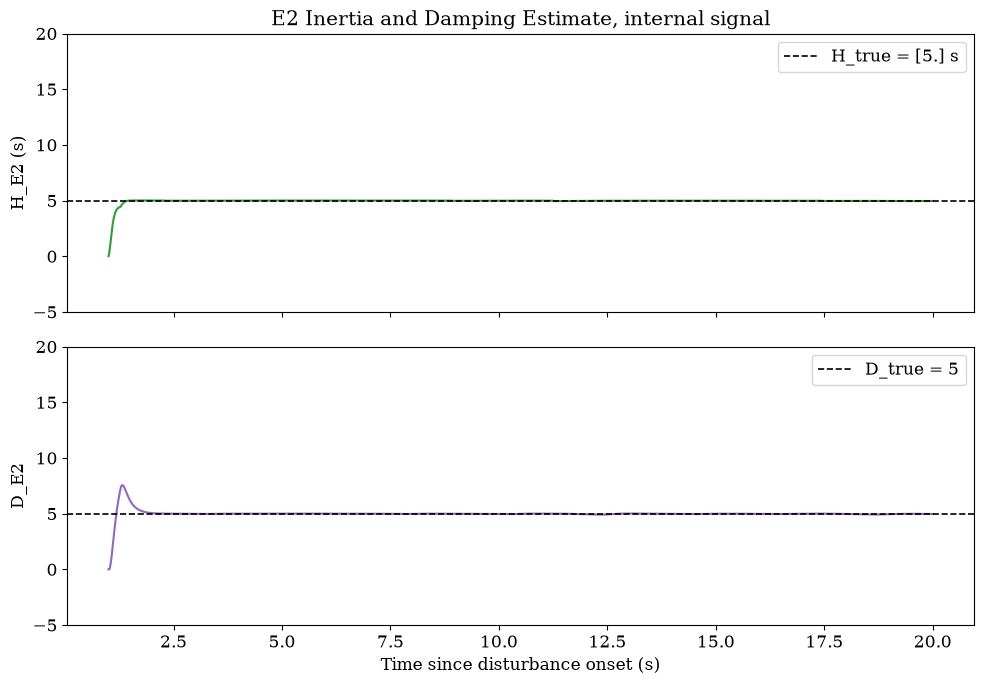

In [62]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(t_est, H_E2, color='tab:green')
axes[0].axhline(H_true, color='k', linewidth=1.2, linestyle='--', label=f'H_true = {H_true} s')
axes[0].set_ylim(-5, 20)
axes[0].set_ylabel('H_E2 (s)')
axes[0].set_title('E2 Inertia and Damping Estimate, internal signal')
axes[0].legend(loc='best')

axes[1].plot(t_est, D_E2, color='tab:purple')
axes[1].axhline(D_configured, color='k', linewidth=1.2, linestyle='--', label=f'D_true = {D_configured}')
axes[1].set_ylim(-5, 20)
axes[1].set_xlabel('Time since disturbance onset (s)')
axes[1].set_ylabel('D_E2')
axes[1].legend(loc='best')
plt.tight_layout()
plt.show()


# Test Simple Inertia Calculation

In [19]:
from algebraic_inertia_estimation import calc_inertia_algebraic

In [20]:
#tds_df.loc[:,"df/dt"] = pd.DataFrame(ss.dae.ts.f).loc[:,ss.REGCV2.dw.a].values
#tds_df

m = calc_inertia_algebraic(tds_df, p0 = 0, t0=0, tf=7.1)
m

#pd.DataFrame(ss.dae.ts.f).loc[:,ss.REGCV2.dw.a]

0.0000          -inf
0.0001          -inf
0.0009          -inf
0.0010          -inf
0.0011          -inf
             ...    
7.0981    441.428589
7.0989    440.224315
7.0990    440.074293
7.0991    439.924385
7.0999    438.729173
Length: 21300, dtype: float64

In [21]:
H_const = ss.REGCV2.M.v[0]/2

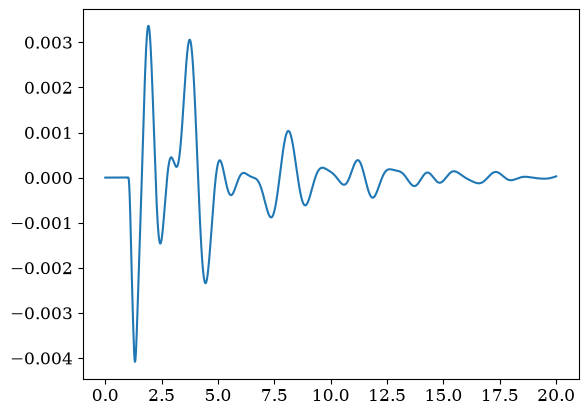

In [22]:
plt.plot(tds_df.index, tds_df["df/dt"])

(1.0, 6.0)

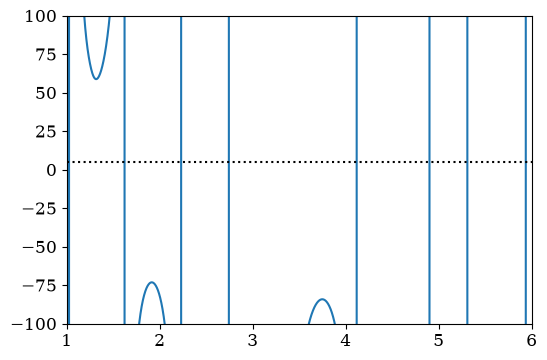

In [32]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(m.index,  m)
ax.axline((0, H_const), slope=0, color="black", linestyle=":")
ax.set_ylim(-100, 100)
ax.set_xlim(1, 6)

In [ ]:
ss.TDS.plot(ss.Bus.v)